In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_probability as tfp
import gpflow
import tensorflow as tf
f64 = gpflow.utilities.to_default_float

from typing import Generator, List, Optional, Tuple

plt.style.use('seaborn-v0_8-colorblind')

2025-11-12 15:41:16.391613: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 15:41:16.393077: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-12 15:41:16.418912: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-12 15:41:16.419905: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-12 15:41:17.060884: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

Autoregrssive kernel reads:
$$
cov(t,t')=\phi^{|t-t'|}\times\frac{\sigma^{2}_{\epsilon}}{1-\phi^{2}}
$$

In the implementation below $\phi$ (persistence) is called lengthscale and $\sigma^{2}_{\epsilon}$ is the variance. 

In [2]:
class K_autoregressive(gpflow.kernels.Kernel):

    def __init__(self):
        super().__init__()
        self.variance = gpflow.Parameter(1.0, transform=tfp.bijectors.SoftClip(
            gpflow.utilities.to_default_float(0.00001),
            gpflow.utilities.to_default_float(1000.0)))
        self.lengthscale = gpflow.Parameter(0.8, transform=tfp.bijectors.SoftClip(
            gpflow.utilities.to_default_float(0.00001),
            gpflow.utilities.to_default_float(1000.0)))


    #@params_as_tensors
    def K(self, X, X2=None):
        if X2 is None:
            X2 = X

        n = int(X.shape[0])
        m = int(X2.shape[0])

        # Block for experiment 1
        X_matrix = tf.tile(tf.reshape(X[:,0],(n,1)), (1,m))
        X_matrix_tr = tf.tile(tf.reshape(X2[:,0], (m,1)), (1,n))
        X_matrix_tr = tf.transpose(X_matrix_tr)

        diff_X = tf.math.abs(X_matrix - X_matrix_tr)
        K = self.variance*(self.lengthscale**diff_X)/((1-self.lengthscale)**2)
        
        return K

    #@params_as_tensors
    def K_diag(self, X):
        n = int(X.shape[0]/2)
        diag = tf.reshape(tf.fill(tf.stack([n]), tf.squeeze(self.variance)), (-1,))

        diag = tf.reshape(diag, (-1,))
        return diag


In [3]:
def plotkernelsample(k, ax, xmin=0, xmax=40, title=None):
    xx = np.linspace(xmin, xmax, 300)[:, None]
    ax.plot(xx, np.random.multivariate_normal(np.zeros(300), k(xx), 3).T)
    ax.set_title(title)
    plt.savefig('change_point_example.png')

In [4]:
k = K_autoregressive()

### Structural break in persistence 

In [5]:
np.random.seed(1)

base_k1 = K_autoregressive()
base_k2 = K_autoregressive()

base_k1.lengthscale.assign(0.1)
base_k2.lengthscale.assign(0.8)

base_k1.variance.assign(0.1)
base_k2.variance.assign(0.1)

k = gpflow.kernels.ChangePoints([base_k1, base_k2], [20.0], steepness=3.0)

#f, ax = plt.subplots(1, 1, figsize=(8, 3))
#plotkernelsample(k, ax)

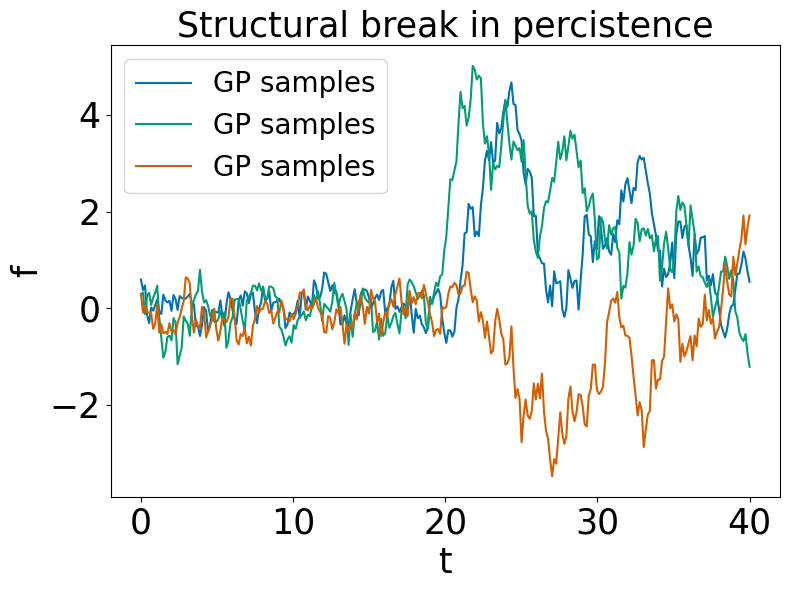

In [6]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
xmin=0
xmax=40

xx = np.linspace(xmin, xmax, 300)[:, None]
ax.plot(xx, np.random.multivariate_normal(np.zeros(300), k(xx), 3).T, label='GP samples')
ax.set_title('Structural break in percistence',fontsize = 25.0)
ax.set_xlabel('t', fontsize = 25.0) 
ax.set_ylabel('f', fontsize = 25.0) 
ax.tick_params(axis='both', which='major', labelsize=25)
ax.tick_params(axis='both', which='minor', labelsize=25)
plt.legend(fontsize = 20.0)
plt.tight_layout()
plt.savefig('gp_samples_autoregressive_break_persistence.png')

### No structural break in persistence 

In [74]:
np.random.seed(1)

base_k1 = K_autoregressive()
base_k2 = K_autoregressive()

base_k1.lengthscale.assign(0.8)
base_k2.lengthscale.assign(0.8)

base_k1.variance.assign(0.1)
base_k2.variance.assign(0.1)

k = gpflow.kernels.ChangePoints([base_k1, base_k2], [20.0], steepness=3.0)

#f, ax = plt.subplots(1, 1, figsize=(8, 3))
#plotkernelsample(k, ax)

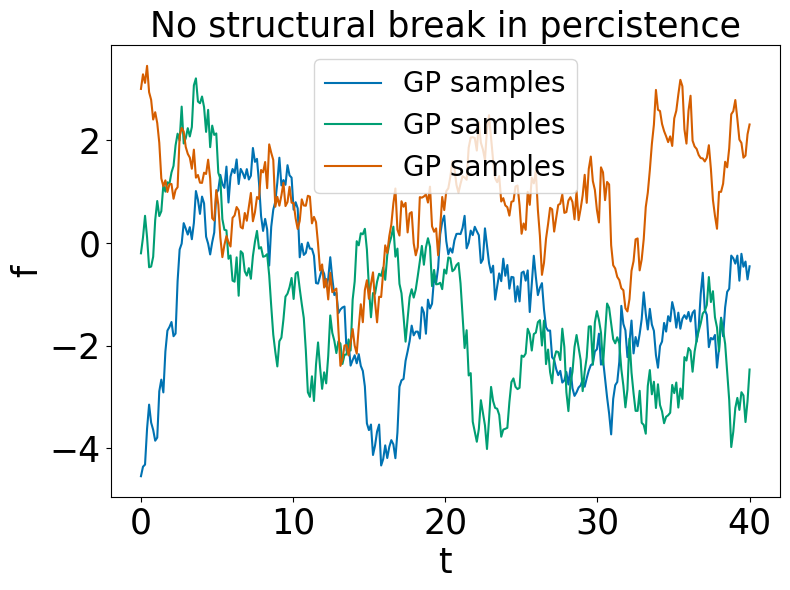

In [75]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
xmin=0
xmax=40

xx = np.linspace(xmin, xmax, 300)[:, None]
ax.plot(xx, np.random.multivariate_normal(np.zeros(300), k(xx), 3).T, label='GP samples')
ax.set_title('No structural break in percistence',fontsize = 25.0)
ax.set_xlabel('t', fontsize = 25.0) 
ax.set_ylabel('f', fontsize = 25.0) 
ax.tick_params(axis='both', which='major', labelsize=25)
ax.tick_params(axis='both', which='minor', labelsize=25)
plt.legend(fontsize = 20.0)
plt.tight_layout()
plt.savefig('gp_samples_autoregressive_no_break_persistence.png')

### Structural break in variance

In [76]:
np.random.seed(1)

base_k1 = K_autoregressive()
base_k2 = K_autoregressive()

base_k1.lengthscale.assign(0.8)
base_k2.lengthscale.assign(0.8)

base_k1.variance.assign(0.1)
base_k2.variance.assign(0.5)

k = gpflow.kernels.ChangePoints([base_k1, base_k2], [20.0], steepness=3.0)

#f, ax = plt.subplots(1, 1, figsize=(8, 3))
#plotkernelsample(k, ax)

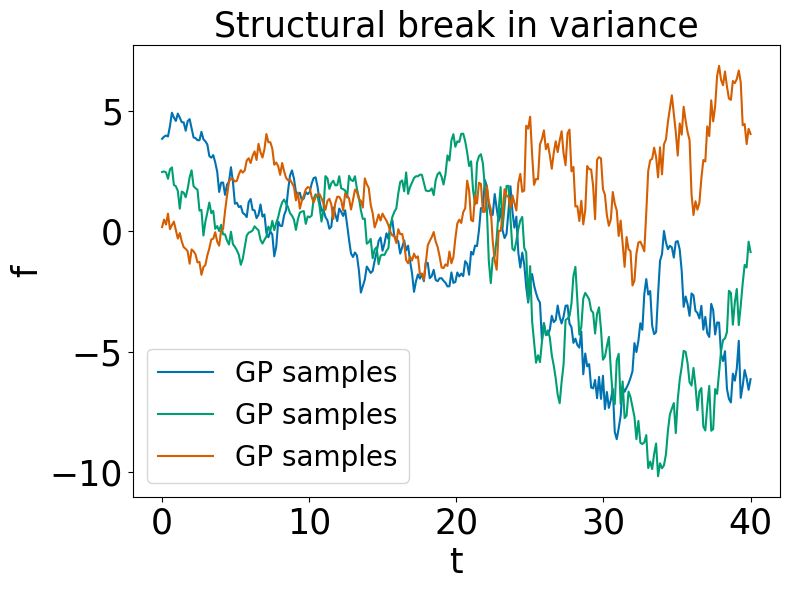

In [77]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
xmin=0
xmax=40

xx = np.linspace(xmin, xmax, 300)[:, None]
ax.plot(xx, np.random.multivariate_normal(np.zeros(300), k(xx), 3).T, label='GP samples')
ax.set_title('Structural break in variance',fontsize = 25.0)
ax.set_xlabel('t', fontsize = 25.0) 
ax.set_ylabel('f', fontsize = 25.0) 
ax.tick_params(axis='both', which='major', labelsize=25)
ax.tick_params(axis='both', which='minor', labelsize=25)
plt.legend(fontsize = 20.0)
plt.tight_layout()
plt.savefig('gp_samples_autoregressive_break_variance.png')

In [78]:
np.random.seed(1)

base_k1 = K_autoregressive()
base_k2 = K_autoregressive()

base_k1.lengthscale.assign(0.8)
base_k2.lengthscale.assign(0.8)

base_k1.variance.assign(0.1)
base_k2.variance.assign(0.1)

k = gpflow.kernels.ChangePoints([base_k1, base_k2], [20.0], steepness=3.0)

#f, ax = plt.subplots(1, 1, figsize=(8, 3))
#plotkernelsample(k, ax)

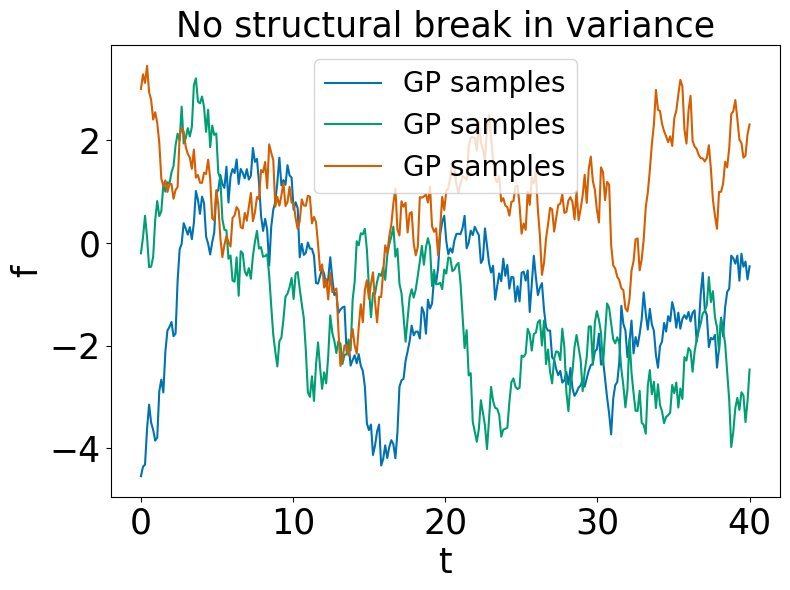

In [79]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
xmin=0
xmax=40

xx = np.linspace(xmin, xmax, 300)[:, None]
ax.plot(xx, np.random.multivariate_normal(np.zeros(300), k(xx), 3).T, label='GP samples')
ax.set_title('No structural break in variance',fontsize = 25.0)
ax.set_xlabel('t', fontsize = 25.0) 
ax.set_ylabel('f', fontsize = 25.0) 
ax.tick_params(axis='both', which='major', labelsize=25)
ax.tick_params(axis='both', which='minor', labelsize=25)
plt.legend(fontsize = 20.0)
plt.tight_layout()
plt.savefig('gp_samples_autoregressive_no_break_variance.png')